# EDA - Análisis Exploratorio de Datos

En este notebook se cargará el dataset de hospital y se realizará un análisis exploratorio para identificar la estructura de los datos, valores faltantes, duplicados y tipos de datos.

In [13]:
import pandas as pd
import os

# Cargar el dataset
# Se intenta cargar desde la ruta actual o desde la carpeta Exam_2025
filename = '251111_hospital.csv'
possible_paths = [filename, os.path.join('Exam_2025', filename)]

file_path = None
for path in possible_paths:
    if os.path.exists(path):
        file_path = path
        break

if file_path:
    print(f"Cargando archivo desde: {file_path}")
    df = pd.read_csv(file_path, sep='|')
    # Mostrar las primeras filas y la dimensión del dataframe
    print(f"Dimensiones del dataset: {df.shape}")
    display(df.head())
else:
    print(f"Error: No se encontró el archivo {filename} en ninguna de las rutas buscadas.")
    print(f"Directorio actual: {os.getcwd()}")

Cargando archivo desde: 251111_hospital.csv
Dimensiones del dataset: (4772, 22)


,periodo,periodo_estudio,paridad,edad_madre,nacionalidad,estado_civil_madre,lugar_control_comuna,embarazo_controlado,embarazo_gemelar,lugar_parto,...,condicion_rn,sexo_rn,peso_nacimiento,edad_gestacional,antropometria,apgar_1min,apgar_5min,hospitalizado,lm_inmediato,acompanante
0,10-2020,PANDEMICO,PRIMIPARA,33,CHILENA,CONVIVIENTE,COLTAUCO,CONTROLADO,NO,PARTO HOSP,...,NACIDO VIVO,MASCULINO,4085,41,AEG,3,7,NO,NO,NO
1,10-2020,PANDEMICO,MULTIPARA,22,CHILENA,SOLTERA,RANCAGUA,CONTROLADO,NO,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2660,37,AEG,6,8,NO,NO,NO
2,12-2020,PANDEMICO,MULTIPARA,37,CHILENA,CONVIVIENTE,RENGO,CONTROLADO,SI,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2750,35,AEG,7,8,NO,NO,NO
3,11-2020,PANDEMICO,MULTIPARA,40,CHILENA,CONVIVIENTE,RENGO,CONTROLADO,SI,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2485,36,AEG,7,8,NO,NO,NO
4,02-2021,PANDEMICO,MULTIPARA,33,CHILENA,CASADA,RANCAGUA,CONTROLADO,SI,PARTO HOSP,...,NACIDO VIVO,FEMENINO,2810,38,AEG,7,8,NO,NO,NO


## Resumen Estadístico
A continuación se presenta un resumen estadístico de las variables numéricas y categóricas.

In [41]:

pd.set_option('display.max_columns', None)
df.describe(include='all')

,periodo_estudio,paridad,edad_madre,nacionalidad,estado_civil_madre,lugar_control_comuna,embarazo_controlado,embarazo_gemelar,lugar_parto,tipo_parto,tipo_cesarea,condicion_rn,sexo_rn,peso_nacimiento,edad_gestacional,antropometria,apgar_1min,apgar_5min,hospitalizado,lm_inmediato,acompanante
count,4770,4770,4770.000000,4770,4770,4770,4770,4770,4770,4770,4770,4770,4770,4770.000000,4770.000000,4770,4770.000000,4770.000000,4770,4770,4770
unique,2,3,NaN,17,6,54,2,2,2,2,4,5,3,NaN,NaN,5,NaN,NaN,3,4,3
top,PREPANDEMICO,MULTIPARA,NaN,CHILENA,CONVIVIENTE,RANCAGUA,CONTROLADO,NO,PARTO HOSP,CESAREA,NO APLICA,NACIDO VIVO,MASCULINO,NaN,NaN,AEG,NaN,NaN,NO,SI,SI
freq,3129,2842,NaN,3924,2118,2147,4657,4619,4756,2759,2011,4664,2435,NaN,NaN,3623,NaN,NaN,3948,3283,3980
mean,NaN,NaN,27.789937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3125.462474,37.698532,NaN,8.176310,8.735430,NaN,NaN,NaN
std,NaN,NaN,6.216772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,756.068051,3.527458,NaN,1.715857,1.523157,NaN,NaN,NaN
min,NaN,NaN,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,9.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,23.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2845.000000,37.000000,NaN,8.000000,9.000000,NaN,NaN,NaN
50%,NaN,NaN,27.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3242.500000,39.000000,NaN,9.000000,9.000000,NaN,NaN,NaN
75%,NaN,NaN,32.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3585.000000,40.000000,NaN,9.000000,9.000000,NaN,NaN,NaN


## Valores Faltantes
Verificamos si existen celdas sin información (NaN).

In [15]:
missing_values = df.isnull().sum()
print("Valores faltantes por columna:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("\nNo se encontraron valores faltantes en el dataset.")

Valores faltantes por columna:
Series([], dtype: int64)

No se encontraron valores faltantes en el dataset.


## Duplicados
Verificamos si existen filas completamente duplicadas.

In [16]:
duplicates = df.duplicated().sum()
print(f"Cantidad de filas duplicadas: {duplicates}")

if duplicates > 0:
    print("Se han detectado registros duplicados.")
    df = df.drop_duplicates()

Cantidad de filas duplicadas: 2
Se han detectado registros duplicados.


## Tipos de Datos y Formato
Revisamos los tipos de datos de cada columna para detectar posibles fallas de formato (ej. números leídos como objetos).

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4770 entries, 0 to 4771
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   periodo               4770 non-null   object
 1   periodo_estudio       4770 non-null   object
 2   paridad               4770 non-null   object
 3   edad_madre            4770 non-null   int64 
 4   nacionalidad          4770 non-null   object
 5   estado_civil_madre    4770 non-null   object
 6   lugar_control_comuna  4770 non-null   object
 7   embarazo_controlado   4770 non-null   object
 8   embarazo_gemelar      4770 non-null   object
 9   lugar_parto           4770 non-null   object
 10  tipo_parto            4770 non-null   object
 11  tipo_cesarea          4770 non-null   object
 12  condicion_rn          4770 non-null   object
 13  sexo_rn               4770 non-null   object
 14  peso_nacimiento       4770 non-null   int64 
 15  edad_gestacional      4770 non-null   int64

# Feature Selection
En esta sección se seleccionarán las características más relevantes para predecir la variable objetivo `periodo_estudio`.
Se eliminará la variable `periodo` y se aplicarán pruebas estadísticas (Chi2 para categóricas y ANOVA para numéricas).

In [18]:
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [19]:
# Eliminar la columna 'periodo' si existe
if 'periodo' in df.columns:
    df = df.drop(columns=['periodo'])
    print("Columna 'periodo' eliminada.")

Columna 'periodo' eliminada.


In [20]:
# Definir variable objetivo y características
target_col = 'periodo_estudio'
X = df.drop(columns=[target_col])
y = df[target_col]

# Codificar la variable objetivo
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

# Separar columnas numéricas y categóricas
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Variables Categóricas ({len(cat_cols)}): {list(cat_cols)}")
print(f"Variables Numéricas ({len(num_cols)}): {list(num_cols)}")

Variables Categóricas (15): ['paridad', 'nacionalidad', 'estado_civil_madre', 'lugar_control_comuna', 'embarazo_controlado', 'embarazo_gemelar', 'lugar_parto', 'tipo_parto', 'tipo_cesarea', 'condicion_rn', 'sexo_rn', 'antropometria', 'hospitalizado', 'lm_inmediato', 'acompanante']
Variables Numéricas (5): ['edad_madre', 'peso_nacimiento', 'edad_gestacional', 'apgar_1min', 'apgar_5min']


In [22]:
# Selección de Características Categóricas (Chi2) con Tabla de Estadísticos
X_cat_encoded = pd.get_dummies(X[cat_cols])
chi2_selector = SelectKBest(chi2).fit(X_cat_encoded, y_encoded)
chi2_stats = pd.DataFrame({'Feature': X_cat_encoded.columns, 'Chi2': chi2_selector.scores_, 'P_Value': chi2_selector.pvalues_}).sort_values('Chi2', ascending=False)

print("Top 10 Chi2 Features:")
display(chi2_stats.head(10))

# Seleccionar características significativas (p < 0.05)
selected_cat_names = chi2_stats[chi2_stats['P_Value'] < 0.05]['Feature']


Top 10 Chi2 Features:


,Feature,Chi2,P_Value
110,lm_inmediato_NO DESCRITO,171.063057,4.334992e-39
52,lugar_control_comuna_MOSTAZAL,157.587494,3.808695e-36
88,tipo_cesarea_ELECTIVA,136.840826,1.306492e-31
40,lugar_control_comuna_EXTRASISTEMA,132.392818,1.227587e-30
112,acompanante_NO,90.099006,2.265355e-21
81,embarazo_controlado_SIN CONTROL,63.136087,1.929072e-15
108,lm_inmediato_NO,49.164592,2.353610e-12
91,tipo_cesarea_URGENCIA,38.310599,6.033406e-10
107,hospitalizado_SI,24.615072,7.000208e-07
90,tipo_cesarea_NO DESCRITO,21.197685,4.142645e-06


In [23]:
# Selección de Características Numéricas (ANOVA) con Tabla de Estadísticos
f_selector = SelectKBest(f_classif, k='all').fit(X[num_cols], y_encoded)
anova_stats = pd.DataFrame({'Feature': num_cols, 'F_Score': f_selector.scores_, 'P_Value': f_selector.pvalues_}).sort_values('F_Score', ascending=False)

print("ANOVA Results:")
display(anova_stats)

# Seleccionar características significativas (p < 0.05)
selected_num_names = anova_stats[anova_stats['P_Value'] < 0.05]['Feature']

ANOVA Results:


,Feature,F_Score,P_Value
4,apgar_5min,14.167387,0.000169
3,apgar_1min,10.052890,0.001531
0,edad_madre,9.609430,0.001947
1,peso_nacimiento,4.133195,0.042105
2,edad_gestacional,3.625068,0.056975


In [24]:
# Unir las características seleccionadas en un único DataFrame
df_selected = pd.concat([
    X_cat_encoded[selected_cat_names].reset_index(drop=True),
    X[selected_num_names].reset_index(drop=True),
    y.reset_index(drop=True)
], axis=1)

print(f"Dimensiones del DataFrame final: {df_selected.shape}")
df_selected.head()

Dimensiones del DataFrame final: (4770, 30)


,lm_inmediato_NO DESCRITO,lugar_control_comuna_MOSTAZAL,tipo_cesarea_ELECTIVA,lugar_control_comuna_EXTRASISTEMA,acompanante_NO,embarazo_controlado_SIN CONTROL,lm_inmediato_NO,tipo_cesarea_URGENCIA,hospitalizado_SI,tipo_cesarea_NO DESCRITO,...,lugar_control_comuna_PELEQUEN,hospitalizado_NO,tipo_parto_CESAREA,paridad_PRIMIPARA,lugar_control_comuna_SANTIAGO,apgar_5min,apgar_1min,edad_madre,peso_nacimiento,periodo_estudio
0,False,False,False,False,True,False,True,True,False,False,...,False,True,True,True,False,7,3,33,4085,PANDEMICO
1,False,False,False,False,True,False,True,True,False,False,...,False,True,True,False,False,8,6,22,2660,PANDEMICO
2,False,False,False,False,True,False,True,True,False,False,...,False,True,True,False,False,8,7,37,2750,PANDEMICO
3,False,False,True,False,True,False,True,False,False,False,...,False,True,True,False,False,8,7,40,2485,PANDEMICO
4,False,False,True,False,True,False,True,False,False,False,...,False,True,True,False,False,8,7,33,2810,PANDEMICO


# Model Training (CatBoost)
Entrenamiento del modelo utilizando CatBoost con un 85% de los datos para entrenamiento.

In [25]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Preparar datos (X e y)
X_final = df_selected.drop(columns=['periodo_estudio'])
y_final = df_selected['periodo_estudio']

# Codificar variable objetivo
le = LabelEncoder()
y_final_encoded = le.fit_transform(y_final)

# Split data (85% train, 15% test, random_state=314)
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final_encoded, test_size=0.15, random_state=314)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (4054, 29)
Test set shape: (716, 29)


In [35]:
# Entrenar modelo CatBoost
model = CatBoostClassifier(
    random_state=314, 
    verbose=0)
    #iterations=2000,
    #early_stopping_rounds=50,
    #learning_rate=0.03)

model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [36]:
# Evaluar modelo
y_pred = model.predict(X_test)

# Métricas

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


Accuracy: 0.7304469273743017
Precision: 0.75736568457539
Recall: 0.8918367346938776
F1 Score: 0.8191190253045924


In [37]:
#Metrica de evaluación
s = (0.6*accuracy + 0.4*f1)**(1.3)
print(s)

0.7070258825161202


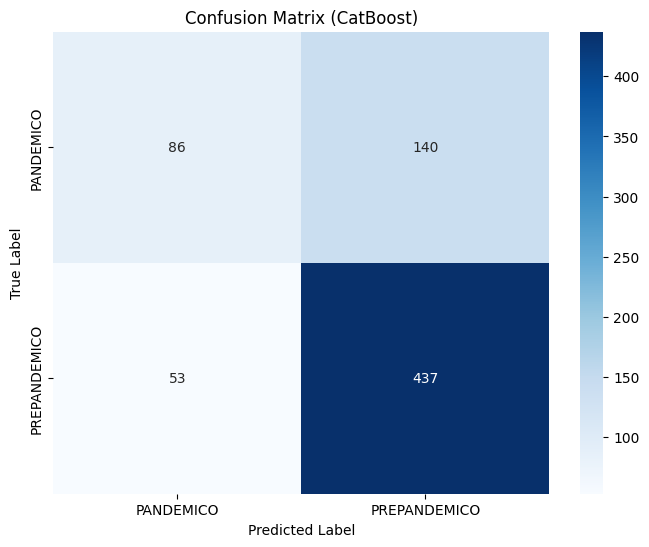

In [38]:
# Visualización: Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (CatBoost)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()